# RSA Amplitude Validation: PPG vs ECG

Compares RSA (Respiratory Sinus Arrhythmia) amplitude calculated from our PPG sensor against ECG (BrainFlow), using the same rolling-buffer pipeline as `hr_amplitude.py`.

**Pipeline (mirrors `hr_amplitude.py`):**
1. Load and trim both signals to the same analysis window
2. Simulate the 10 s rolling buffer + 1 s processing loop
3. NeuroKit2 peak detection → `clean_peaks` (PPG) / R-peaks (ECG) → IBI filter (0.3–2.0 s) → mean HR
4. Feed HR time series into `RealTimeHRVAmplitude` to extract RSA amplitude events
5. Match PPG and ECG events by nearest trough timestamp and print absolute error per event

In [1]:
import numpy as np
import pandas as pd
import neurokit2 as nk
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from collections import deque
import warnings
warnings.filterwarnings('ignore')

# ── Configuration ───────────────────────────────────────────────────────────
PPG_PATH           = "validation_data/ppg_data2.txt"
ECG_EXCEL_PATH     = "validation_data/BrainFlow-RAW_2026-04-02_01-40-52_0.xlsx"
PPG_FS             = 100    # PPG sampling rate in Hz
ECG_FS             = 250    # ECG sampling rate in Hz
START_OFFSET_SEC   = 45     # seconds to skip from the start of each recording
RMSSD_DURATION_SEC = 120    # seconds of data to use for analysis

# Rolling buffer constants (identical to hr_amplitude.py)
BUFFER_SEC           = 10   # rolling buffer length in seconds
PROCESS_INTERVAL_SEC = 1    # HR is computed once per second
MATCH_TOLERANCE_S    = 10.0 # max time gap (s) to consider two events matched

## Load & Trim Data

In [2]:
def load_ppg(path):
    with open(path, 'r') as f:
        return np.array([float(l.strip()) for l in f if l.strip()])

ppg_raw = load_ppg(PPG_PATH)

df = pd.read_excel(ECG_EXCEL_PATH)
ecg_raw = df.iloc[1:, 1].dropna().to_numpy(dtype=float)

ppg_start   = int(START_OFFSET_SEC * PPG_FS)
ppg_trimmed = ppg_raw[ppg_start : ppg_start + int(RMSSD_DURATION_SEC * PPG_FS)]

ecg_start   = int(START_OFFSET_SEC * ECG_FS)
ecg_trimmed = ecg_raw[ecg_start : ecg_start + int(RMSSD_DURATION_SEC * ECG_FS)]

print(f"PPG trimmed: {len(ppg_trimmed)} samples ({len(ppg_trimmed)/PPG_FS:.1f} s at {PPG_FS} Hz)")
print(f"ECG trimmed: {len(ecg_trimmed)} samples ({len(ecg_trimmed)/ECG_FS:.1f} s at {ECG_FS} Hz)")

PPG trimmed: 12000 samples (120.0 s at 100 Hz)
ECG trimmed: 30000 samples (120.0 s at 250 Hz)


## RSA Helpers

Copied verbatim from `hr_amplitude.py`: `initial_cleaning`, `clean_peaks`, and `RealTimeHRVAmplitude`.

In [10]:
def initial_cleaning(ppg_window, peak_indices, rising_window=5):
    """Remove peaks that sit on a rising edge (stage 1 of clean_peaks)."""
    cleaned = []
    for idx in peak_indices:
        end_idx = min(idx + rising_window + 1, len(ppg_window))
        after = ppg_window[idx:end_idx]
        if len(after) > 1 and all(after[i] < after[i+1] for i in range(len(after)-1)):
            continue
        cleaned.append(idx)
    return cleaned


def clean_peaks(ppg_window, peak_indices, rising_window=5, min_distance=20):
    """Two-stage PPG peak cleaner: rising-edge filter then minimum-distance filter."""
    cleaned = initial_cleaning(ppg_window, peak_indices, rising_window)
    i = 0
    while i < len(cleaned) - 1:
        if cleaned[i+1] - cleaned[i] < min_distance:
            if ppg_window[cleaned[i]] >= ppg_window[cleaned[i+1]]:
                cleaned.pop(i+1)
            else:
                cleaned.pop(i)
        else:
            i += 1
    return cleaned


class RealTimeHRVAmplitude:
    """
    Incrementally detects RSA peaks and troughs in the HR time series
    and emits an amplitude event each time a valid peak->trough pair is confirmed.
    Copied verbatim from hr_amplitude.py.
    """

    def __init__(self):
        self.last_peak_idx    = None
        self.last_peak_hr     = None
        self.amplitudes       = []
        self.last_confirmed_idx = -1
        self.paused           = False

    def reset_peak_state(self, hr_len=0):
        self.last_peak_idx  = None
        self.last_peak_hr   = None
        self.last_confirmed_idx = hr_len - 1

    def update(self, hr_times, hr_values):
        n = len(hr_values)
        if n < 10:
            return []

        hr = np.array(hr_values, dtype=float)
        CONFIRM_MARGIN = 3

        peaks,   _ = find_peaks( hr, distance=3, prominence=1.5)
        troughs, _ = find_peaks(-hr, distance=3, prominence=1.5)

        events = sorted(
            [(i, 'peak')   for i in peaks] +
            [(i, 'trough') for i in troughs]
        )

        feedback = []
        for idx, event_type in events:
            if idx <= self.last_confirmed_idx:
                continue
            if idx >= n - CONFIRM_MARGIN:
                continue

            if event_type == 'peak':
                self.last_peak_idx = idx
                self.last_peak_hr  = hr[idx]
                self.last_confirmed_idx = idx

            elif event_type == 'trough':
                self.last_confirmed_idx = idx
                if self.last_peak_hr is not None and self.last_peak_idx is not None:
                    amplitude = self.last_peak_hr - hr[idx]
                    if amplitude > 5.0:
                        self.amplitudes.append(amplitude)
                        smooth_amp = float(np.mean(self.amplitudes[-3:]))

                        peak_t   = hr_times[self.last_peak_idx]
                        trough_t = hr_times[idx]
                        half_period = trough_t - peak_t
                        breathing_rate = (60.0 / (2 * half_period)) if half_period > 0 else 0.0

                        feedback.append({
                            'peak_idx':           self.last_peak_idx,
                            'trough_idx':         idx,
                            'peak_hr':            float(self.last_peak_hr),
                            'trough_hr':          float(hr[idx]),
                            'amplitude':          smooth_amp,
                            'breathing_rate_bpm': breathing_rate,
                        })
                    self.last_peak_hr  = None
                    self.last_peak_idx = None

        return feedback

## Pipeline Functions

Each function simulates the offline batch version of the rolling-buffer loop in `collect_and_analyze_amplitude()` from `hr_amplitude.py`.
- **PPG**: `nk.ppg_process` → `clean_peaks` → IBI filter → mean HR → `RealTimeHRVAmplitude`
- **ECG**: `nk.ecg_process` → R-peaks → IBI filter → mean HR → `RealTimeHRVAmplitude`

In [11]:
def compute_rsa_ppg(signal, fs):
    """
    Offline simulation of the hr_amplitude.py rolling-buffer pipeline for PPG.

    Returns
    -------
    hr_times  : list[float]  timestamps (s) of each HR estimate
    hr_values : list[float]  HR in BPM parallel to hr_times
    events    : list[dict]   RSA amplitude events (same schema as RealTimeHRVAmplitude.update)
    """
    buffer_samples   = BUFFER_SEC * fs
    process_interval = PROCESS_INTERVAL_SEC * fs

    ppg_buffer = deque(maxlen=buffer_samples)
    hr_times   = []
    hr_values  = []
    tracker    = RealTimeHRVAmplitude()
    events     = []
    last_process = 0

    for i, sample in enumerate(signal):
        ppg_buffer.append(sample)
        sample_count = i + 1

        # Process once per process_interval samples, once buffer is at least 5 s full
        if sample_count - last_process >= process_interval and len(ppg_buffer) >= fs * 5:
            last_process = sample_count
            buf = np.array(ppg_buffer)

            try:
                signals_df, _ = nk.ppg_process(buf, sampling_rate=fs)
                raw_peaks = list(np.where(signals_df['PPG_Peaks'] == 1)[0]) \
                    if 'PPG_Peaks' in signals_df else []
                cleaned = clean_peaks(buf, raw_peaks)

                if len(cleaned) >= 2:
                    ibi = np.diff(cleaned) / fs
                    ibi = ibi[(ibi > 0.3) & (ibi < 2.0)]  # 30–200 bpm range
                    if len(ibi) > 0:
                        hr_times.append(sample_count / fs)
                        hr_values.append(60.0 / np.mean(ibi))
            except Exception:
                pass

            new_events = tracker.update(hr_times, hr_values)
            events.extend(new_events)

    return hr_times, hr_values, events

In [12]:
def compute_rsa_ecg(signal, fs):
    """
    Offline simulation of the rolling-buffer pipeline for ECG.
    Uses nk.ecg_process R-peaks directly (no clean_peaks — ECG peaks are clean natively).

    Returns
    -------
    hr_times  : list[float]
    hr_values : list[float]
    events    : list[dict]
    """
    buffer_samples   = BUFFER_SEC * fs
    process_interval = PROCESS_INTERVAL_SEC * fs

    ecg_buffer = deque(maxlen=buffer_samples)
    hr_times   = []
    hr_values  = []
    tracker    = RealTimeHRVAmplitude()
    events     = []
    last_process = 0

    for i, sample in enumerate(signal):
        ecg_buffer.append(sample)
        sample_count = i + 1

        if sample_count - last_process >= process_interval and len(ecg_buffer) >= fs * 5:
            last_process = sample_count
            buf = np.array(ecg_buffer)

            try:
                signals_df, info = nk.ecg_process(buf, sampling_rate=fs)
                rpeaks = info.get('ECG_R_Peaks', [])

                if len(rpeaks) >= 2:
                    ibi = np.diff(rpeaks) / fs
                    ibi = ibi[(ibi > 0.3) & (ibi < 2.0)]
                    if len(ibi) > 0:
                        hr_times.append(sample_count / fs)
                        hr_values.append(60.0 / np.mean(ibi))
            except Exception:
                pass

            new_events = tracker.update(hr_times, hr_values)
            events.extend(new_events)

    return hr_times, hr_values, events

## Run Both Pipelines

This simulates the full session for both signals. May take ~30–60 s depending on signal length.

In [13]:
print("Running PPG RSA pipeline...")
ppg_hr_times, ppg_hr_values, ppg_events = compute_rsa_ppg(ppg_trimmed, PPG_FS)
print(f"  PPG: {len(ppg_hr_values)} HR samples, {len(ppg_events)} amplitude events")

print("\nRunning ECG RSA pipeline...")
ecg_hr_times, ecg_hr_values, ecg_events = compute_rsa_ecg(ecg_trimmed, ECG_FS)
print(f"  ECG: {len(ecg_hr_values)} HR samples, {len(ecg_events)} amplitude events")

Running PPG RSA pipeline...
  PPG: 116 HR samples, 6 amplitude events

Running ECG RSA pipeline...
  ECG: 116 HR samples, 6 amplitude events


## Match Events & Print Absolute Error

Each PPG amplitude event is matched to the nearest-in-time ECG amplitude event (by trough timestamp).
Events are considered matched only if they are within `MATCH_TOLERANCE_S` seconds of each other.
The absolute error is `|PPG amplitude − ECG amplitude|` in BPM.

In [14]:
# Extract trough times and amplitudes for each signal
ppg_event_times = np.array([ppg_hr_times[e['trough_idx']] for e in ppg_events])
ecg_event_times = np.array([ecg_hr_times[e['trough_idx']] for e in ecg_events])

ppg_amps = np.array([e['amplitude'] for e in ppg_events])
ecg_amps = np.array([e['amplitude'] for e in ecg_events])

# Greedy nearest-neighbour matching (each ECG event used at most once)
matched_rows = []
ecg_used = set()

for i, (pt, pa) in enumerate(zip(ppg_event_times, ppg_amps)):
    if len(ecg_event_times) == 0:
        break
    diffs = np.abs(ecg_event_times - pt)
    j = int(np.argmin(diffs))
    if diffs[j] <= MATCH_TOLERANCE_S and j not in ecg_used:
        ecg_used.add(j)
        matched_rows.append({
            'Event': i + 1,
            'PPG_time_s':        round(float(pt), 2),
            'ECG_time_s':        round(float(ecg_event_times[j]), 2),
            'Time_diff_s':       round(float(diffs[j]), 2),
            'PPG_amplitude_BPM': round(float(pa), 2),
            'ECG_amplitude_BPM': round(float(ecg_amps[j]), 2),
            'Absolute_error_BPM': round(abs(float(pa) - float(ecg_amps[j])), 2),
        })

df_matched = pd.DataFrame(matched_rows)

print(f"PPG amplitude events: {len(ppg_events)}")
print(f"ECG amplitude events: {len(ecg_events)}")
print(f"Matched pairs (tolerance ±{MATCH_TOLERANCE_S} s): {len(df_matched)}")
print()

if len(df_matched) > 0:
    display(df_matched)
    print()
    print("=" * 50)
    print(f"  Mean absolute error:   {df_matched['Absolute_error_BPM'].mean():.2f} BPM")
    print(f"  Median absolute error: {df_matched['Absolute_error_BPM'].median():.2f} BPM")
    print(f"  Min absolute error:    {df_matched['Absolute_error_BPM'].min():.2f} BPM")
    print(f"  Max absolute error:    {df_matched['Absolute_error_BPM'].max():.2f} BPM")
    print("=" * 50)
else:
    print("No matched pairs found. Try increasing MATCH_TOLERANCE_S.")

PPG amplitude events: 6
ECG amplitude events: 6
Matched pairs (tolerance ±10.0 s): 6



,Event,PPG_time_s,ECG_time_s,Time_diff_s,PPG_amplitude_BPM,ECG_amplitude_BPM,Absolute_error_BPM
0,1,26.0,25.0,1.0,30.56,30.17,0.39
1,2,42.0,42.0,0.0,28.70,28.96,0.26
2,3,59.0,58.0,1.0,27.90,27.70,0.20
3,4,76.0,75.0,1.0,25.99,26.06,0.07
4,5,94.0,93.0,1.0,26.61,26.12,0.49
5,6,111.0,111.0,0.0,28.83,28.92,0.09



  Mean absolute error:   0.25 BPM
  Median absolute error: 0.23 BPM
  Min absolute error:    0.07 BPM
  Max absolute error:    0.49 BPM


## HR Comparison: PPG vs ECG

Match the ~1 Hz heart rate estimates from both pipelines by nearest timestamp (tolerance ±2 s) and compute the absolute error per sample.


In [15]:
HR_MATCH_TOLERANCE_S = 2.0  # max time gap (s) to match a PPG HR sample to an ECG HR sample

ppg_hr_arr = np.array(ppg_hr_values)
ecg_hr_arr = np.array(ecg_hr_values)
ppg_t_arr  = np.array(ppg_hr_times)
ecg_t_arr  = np.array(ecg_hr_times)

hr_rows = []
ecg_hr_used = set()

for i, (pt, ph) in enumerate(zip(ppg_t_arr, ppg_hr_arr)):
    if len(ecg_t_arr) == 0:
        break
    diffs = np.abs(ecg_t_arr - pt)
    j = int(np.argmin(diffs))
    if diffs[j] <= HR_MATCH_TOLERANCE_S and j not in ecg_hr_used:
        ecg_hr_used.add(j)
        hr_rows.append({
            'Sample':           i + 1,
            'PPG_time_s':       round(float(pt), 2),
            'ECG_time_s':       round(float(ecg_t_arr[j]), 2),
            'Time_diff_s':      round(float(diffs[j]), 2),
            'PPG_HR_BPM':       round(float(ph), 2),
            'ECG_HR_BPM':       round(float(ecg_hr_arr[j]), 2),
            'Absolute_error_BPM': round(abs(float(ph) - float(ecg_hr_arr[j])), 2),
        })

df_hr = pd.DataFrame(hr_rows)

print(f"PPG HR samples: {len(ppg_hr_values)}")
print(f"ECG HR samples: {len(ecg_hr_values)}")
print(f"Matched HR pairs (tolerance ±{HR_MATCH_TOLERANCE_S} s): {len(df_hr)}")
print()

if len(df_hr) > 0:
    display(df_hr)
    print()
    print("=" * 50)
    print(f"  Mean absolute error:   {df_hr['Absolute_error_BPM'].mean():.2f} BPM")
    print(f"  Median absolute error: {df_hr['Absolute_error_BPM'].median():.2f} BPM")
    print(f"  Min absolute error:    {df_hr['Absolute_error_BPM'].min():.2f} BPM")
    print(f"  Max absolute error:    {df_hr['Absolute_error_BPM'].max():.2f} BPM")
    print("=" * 50)
else:
    print("No matched HR pairs found. Try increasing HR_MATCH_TOLERANCE_S.")


PPG HR samples: 116
ECG HR samples: 116
Matched HR pairs (tolerance ±2.0 s): 116



,Sample,PPG_time_s,ECG_time_s,Time_diff_s,PPG_HR_BPM,ECG_HR_BPM,Absolute_error_BPM
0,1,5.0,5.0,0.0,67.80,69.36,1.57
1,2,6.0,6.0,0.0,69.12,71.16,2.03
2,3,7.0,7.0,0.0,72.16,74.95,2.78
3,4,8.0,8.0,0.0,73.96,78.63,4.67
4,5,9.0,9.0,0.0,77.42,80.34,2.92
...,...,...,...,...,...,...,...
111,112,116.0,116.0,0.0,79.91,82.83,2.92
112,113,117.0,117.0,0.0,84.42,87.56,3.15
113,114,118.0,118.0,0.0,88.98,92.72,3.73
114,115,119.0,119.0,0.0,96.77,97.23,0.46



  Mean absolute error:   2.63 BPM
  Median absolute error: 2.55 BPM
  Min absolute error:    0.18 BPM
  Max absolute error:    5.49 BPM


## Plots

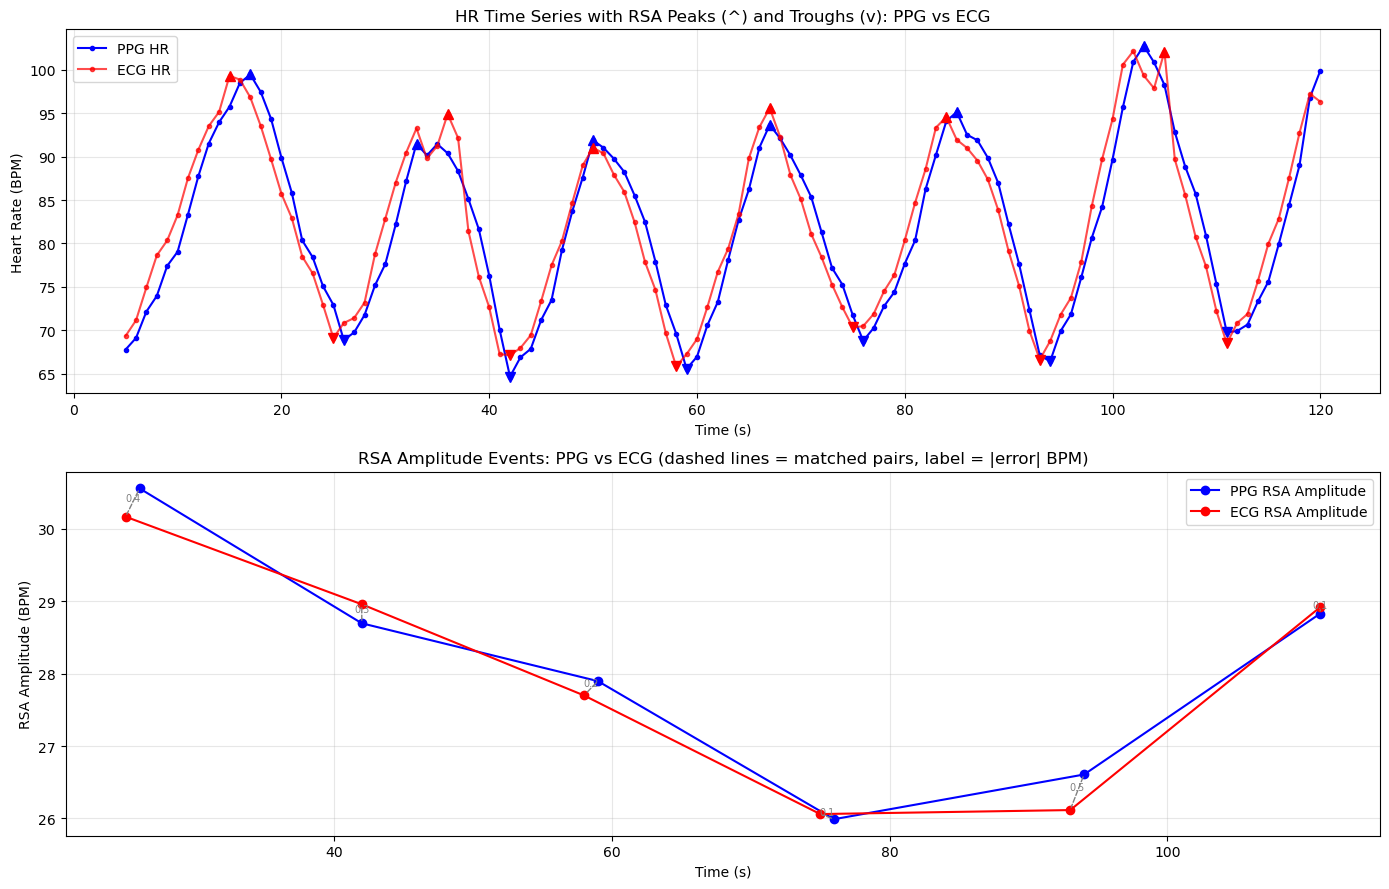

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# ── Chart 1: HR time series ──────────────────────────────────────────────────
ax1 = axes[0]
ax1.plot(ppg_hr_times, ppg_hr_values, 'b-o', markersize=3, label='PPG HR')
ax1.plot(ecg_hr_times, ecg_hr_values, 'r-o', markersize=3, label='ECG HR', alpha=0.7)

# Mark RSA peaks (^) and troughs (v) on HR chart
for e in ppg_events:
    ax1.plot(ppg_hr_times[e['peak_idx']],   e['peak_hr'],   '^', color='blue',  markersize=7)
    ax1.plot(ppg_hr_times[e['trough_idx']], e['trough_hr'], 'v', color='blue',  markersize=7)
for e in ecg_events:
    ax1.plot(ecg_hr_times[e['peak_idx']],   e['peak_hr'],   '^', color='red',   markersize=7)
    ax1.plot(ecg_hr_times[e['trough_idx']], e['trough_hr'], 'v', color='red',   markersize=7)

ax1.set_ylabel('Heart Rate (BPM)')
ax1.set_xlabel('Time (s)')
ax1.set_title('HR Time Series with RSA Peaks (^) and Troughs (v): PPG vs ECG')
ax1.legend()
ax1.grid(True, alpha=0.3)

# ── Chart 2: RSA amplitude events ────────────────────────────────────────────
ax2 = axes[1]
if len(ppg_event_times) > 0:
    ax2.plot(ppg_event_times, ppg_amps, 'b-o', markersize=6, label='PPG RSA Amplitude')
if len(ecg_event_times) > 0:
    ax2.plot(ecg_event_times, ecg_amps, 'r-o', markersize=6, label='ECG RSA Amplitude')

# Draw vertical lines connecting matched pairs
for row in matched_rows:
    mid_t = (row['PPG_time_s'] + row['ECG_time_s']) / 2
    ax2.annotate('', xy=(row['ECG_time_s'], row['ECG_amplitude_BPM']),
                 xytext=(row['PPG_time_s'], row['PPG_amplitude_BPM']),
                 arrowprops=dict(arrowstyle='-', color='gray', lw=1.0, linestyle='dashed'))
    ax2.text(mid_t, (row['PPG_amplitude_BPM'] + row['ECG_amplitude_BPM']) / 2,
             f"{row['Absolute_error_BPM']:.1f}",
             fontsize=7, ha='center', va='bottom', color='gray')

ax2.set_ylabel('RSA Amplitude (BPM)')
ax2.set_xlabel('Time (s)')
ax2.set_title('RSA Amplitude Events: PPG vs ECG (dashed lines = matched pairs, label = |error| BPM)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()